# Introduction

This notebook introduces the fundamental concepts of Computer Vision through hands-on coding exercises. You will start by loading and visualizing images, followed by essential preprocessing techniques such as resizing, normalization, and grayscale conversion. Next, we explore feature extraction methods like edge detection and filtering, helping understand how computers recognize patterns in images. Finally, we introduce deep learning for image classification, covering the basics of Convolutional Neural Networks (CNNs) and training a simple model. By the end, you will have a structured understanding of key Computer Vision techniques and their practical applications.

<center><img src="https://opencv.org/wp-content/uploads/2023/12/computer-vision-and-image-processing.jpg" width="400"></center>

## **What is MNIST?**

The **MNIST dataset** is a collection of **handwritten digits (0-9)** commonly used for training image processing and machine learning models. It contains:

- **60,000 training images** and **10,000 test images**.
- Each image is **28x28 pixels**, grayscale, with pixel values ranging from **0 to 255**.
- Labels range from **0 to 9**, representing the digit shown in the image.
- MNIST is a benchmark dataset for classification models in **deep learning**.

<center><img src="https://corochann.com/wp-content/uploads/2021/09/mnist_plot.png" width="400"></center>

## **Module Initialization: Importing Required Libraries**  

1. **`torch`** – The core PyTorch library for tensor computations and deep learning operations.  
2. **`torch.nn`** – Provides neural network layers (`nn.Module`), activation functions, loss functions, and optimization utilities.  
3. **`torchvision.transforms`** – Contains image transformation utilities for preprocessing datasets (e.g., converting images to tensors).  
4. **`torchvision.datasets`** – Provides access to common deep learning datasets like MNIST, CIFAR-10, and ImageNet.  
5. **`torch.autograd.Variable`** – Enables automatic differentiation and gradient computation for training neural networks.  
6. **`torchsummary.summary`** – Generates a detailed model summary, displaying layer information, output shapes, and total parameters.  

These imports set up the foundation for **loading datasets, defining models, training neural networks, and analyzing deep learning architectures in PyTorch**.  


In [3]:
# Importing the necessary libraries

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.autograd import Variable
from torchsummary import summary

# **MNIST Classification with a FFNN**


## What is a Feedforward Neural Network (FFNN)?

A **Feedforward Neural Network (FFNN)** is the simplest type of artificial neural network in which:
- Data flows in **one direction**, from input to output.
- It consists of **fully connected (dense) layers**.
- Uses **activation functions** like ReLU to introduce non-linearity.

## **How FFNN Processes MNIST Data**


1. **Flattening:** Each 28x28 image is converted into a **784-dimensional vector**.
2. **Hidden Layers:** Uses multiple dense layers with **ReLU activation**.
3. **Output Layer:** 10 neurons (one for each digit 0-9) with **Softmax activation**.

In [4]:
root_folder = '/content/drive/My Drive/IK ML Resources/Computer Vision 1'

## **STEP 1: LOADING DATASET**

In [5]:
'''
STEP 1: LOADING DATASET
'''

# MNIST contains 60,000 training images and 10,000 test images of handwritten digits (0-9)

# Load the training dataset
train_dataset = dsets.MNIST(root=root_folder,                 # Directory where the dataset will be stored
                            train=True,                       # Load training set
                            transform=transforms.ToTensor(),  # Convert images to PyTorch tensors
                            download=True)                    # Download dataset if not already present

# Load the test dataset
test_dataset = dsets.MNIST(root=root_folder,                   # Directory where the dataset will be stored
                           train=False,                        # Load test set
                           transform=transforms.ToTensor())    # Convert images to PyTorch tensors (no need to download again)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 55.1kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 239kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]


## **STEP 2: MAKING DATASET ITERABLE**

In this step, we **prepare the dataset for efficient processing** by:  

1. **Defining Batch Size (`batch_size=100`)**  
   - Instead of loading one image at a time, we process data in batches for efficiency.  
   - Larger batch sizes **speed up training** but require more memory.  

2. **Calculating Number of Epochs (`num_epochs`)**  
   - Epochs define how many times the model sees the entire dataset.  
   - Computed as:  
     ```
     num_epochs = total_iterations / (total_samples / batch_size)
     ```

3. **Creating `DataLoader` Objects**  
   - **`train_loader`**: Loads **training data in batches** with **shuffling enabled** (randomized order).  
   - **`test_loader`**: Loads **test data** without shuffling (order doesn't affect evaluation).  

This setup ensures **efficient data feeding** into the model during training and evaluation.


In [6]:
'''
STEP 2: MAKING DATASET ITERABLE
'''

batch_size = 100  # Number of samples per batch
n_iters = 3000  # Total training iterations

# Compute the number of epochs based on dataset size and iterations
num_epochs = int(n_iters / (len(train_dataset) / batch_size))

# DataLoader for efficient batch processing
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f'Total number of batches in training set: {len(train_loader)}')
print(f'Total number of batches in test set: {len(test_loader)}')

print(f'\nNo. of samples per batch: {batch_size}')
print(f'\nTotal number of epochs: {num_epochs}')


Total number of batches in training set: 600
Total number of batches in test set: 100

No. of samples per batch: 100

Total number of epochs: 5


In [7]:
# Check the value of num_epochs to ensure it's correctly computed
num_epochs

5

In [8]:
# Verify that train_loader is a DataLoader instance
type(train_loader)

torch.utils.data.dataloader.DataLoader

In [9]:
# Fetch the first batch of training data to confirm DataLoader functionality
next(iter(train_loader))

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

## **STEP 3: CREATE MODEL CLASS**

This step defines a Feedforward Neural Network (FNN) using PyTorch's nn.Module. The model consists of multiple fully connected (Linear) layers with ReLU activation functions in between. The input to the network is a flattened image of 28x28 pixels (784 features), and the output is a probability distribution over 10 classes (digits 0-9).

In [8]:
# Define a Feedforward Neural Network model using PyTorch's nn.Module
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initializes the neural network layers.

        Args:
        - input_dim (int): Number of input features (for MNIST, this is 784).
        - hidden_dim (int): Number of neurons in the hidden layers.
        - output_dim (int): Number of output classes (for MNIST, this is 10).
        """
        super(FeedforwardNeuralNetModel, self).__init__()

        # First fully connected (linear) layer: Input layer (784) → Hidden layer (100)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # First ReLU activation function (introduces non-linearity)
        self.relu1 = nn.ReLU()

        # Second fully connected layer: Hidden layer (100) → Hidden layer (100)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Second ReLU activation function
        self.relu2 = nn.ReLU()

        # Third fully connected layer: Hidden layer (100) → Hidden layer (100)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Third ReLU activation function
        self.relu3 = nn.ReLU()

        # Output layer: Hidden layer (100) → Output layer (10)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        Defines the forward pass of the neural network.

        Args:
        - x (Tensor): Input tensor (batch of images).

        Returns:
        - out (Tensor): Output predictions for each class.
        """
        # Pass input through the first linear layer followed by ReLU activation
        out = self.fc1(x)
        out = self.relu1(out)

        # Pass through the second linear layer followed by ReLU activation
        out = self.fc2(out)
        out = self.relu2(out)

        # Pass through the third linear layer followed by ReLU activation
        out = self.fc3(out)
        out = self.relu3(out)

        # Final output layer (no activation function, since this is classification)
        out = self.fc4(out)

        return out


## **STEP 4: INSTANTIATE MODEL CLASS**

In this step, we create an instance of the Feedforward Neural Network (FNN) model using the class we defined earlier. The model takes an input dimension (number of features), a hidden layer size, and an output dimension (number of classes).

Additionally, we use torchsummary to display the model architecture, showing the number of layers, parameters, and output shapes at each stage.

In [9]:
# Define model input size (each image is 28x28 pixels, flattened into 784 features)
input_dim = 28 * 28  # 784 input features
hidden_dim = 100  # Number of neurons in hidden layers
output_dim = 10  # 10 output classes (digits 0-9)

# Instantiate the Feedforward Neural Network model
model = FeedforwardNeuralNetModel(input_dim, hidden_dim, output_dim)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    model = model.to(device)

# Print model summary (Displays layer-wise parameters and shapes)
summary(model, input_size=(1, 784))  # Input size corresponds to a single flattened image


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 100]          78,500
              ReLU-2               [-1, 1, 100]               0
            Linear-3               [-1, 1, 100]          10,100
              ReLU-4               [-1, 1, 100]               0
            Linear-5               [-1, 1, 100]          10,100
              ReLU-6               [-1, 1, 100]               0
            Linear-7                [-1, 1, 10]           1,010
Total params: 99,710
Trainable params: 99,710
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.38
Estimated Total Size (MB): 0.39
----------------------------------------------------------------


In [10]:
summary(model, input_size=(1, 784))  # Generate a model summary with input size (1, 784)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 100]          78,500
              ReLU-2               [-1, 1, 100]               0
            Linear-3               [-1, 1, 100]          10,100
              ReLU-4               [-1, 1, 100]               0
            Linear-5               [-1, 1, 100]          10,100
              ReLU-6               [-1, 1, 100]               0
            Linear-7                [-1, 1, 10]           1,010
Total params: 99,710
Trainable params: 99,710
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.38
Estimated Total Size (MB): 0.39
----------------------------------------------------------------


## **STEP 5: INSTANTIATE LOSS CLASS**

The loss function measures how well the model's predictions match the actual labels. Since this is a multi-class classification task, we use Cross Entropy Loss (nn.CrossEntropyLoss()), which combines Softmax activation and Negative Log Likelihood Loss (NLLLoss). This ensures that the model outputs probabilities for each class and penalizes incorrect predictions accordingly.

In [11]:
# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()  # Combines Softmax and Negative Log Likelihood Loss

## **STEP 6: INSTANTIATE OPTIMIZER CLASS**

The optimizer updates the model's parameters to minimize the loss. We use Stochastic Gradient Descent (SGD), a commonly used optimization algorithm that updates parameters using the computed gradients. The learning rate (lr) determines how much the weights are adjusted in each step.

In [12]:
# Define the learning rate (step size for updating weights)
learning_rate = 0.1  # A higher value speeds up learning but can cause instability

# Initialize the optimizer (SGD - Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(),  # Updates model weights
                            lr=learning_rate)  # Learning rate determines update size

## **STEP 7: TRAIN THE MODEL**

This step trains the neural network by iterating through the dataset multiple times (epochs). The training loop follows these key steps:


1. Forward Pass: The input images are passed through the model to generate predictions (logits).

2. Loss Computation: The loss function compares predictions with actual labels.

3. Backward Pass: Computes gradients using backpropagation.

4. Optimizer Step: Updates model parameters to minimize loss.

5. Optimizer Step: Updates model parameters to minimize loss.

  - The model is evaluated on the test dataset.

  - Predictions are compared with actual labels.

  - Accuracy is calculated and displayed.


### **Training the FFNN on MNIST**


- Uses **CrossEntropyLoss** for multi-class classification.
- Optimizer: **Stochastic Gradient Descent (SGD)** with learning rate **0.1**.
- Trains for **5 epochs** over the dataset.

In [13]:
# Lists to store loss values for plotting
train_losses = []
val_losses = []
iterations = []


# Initialize iteration counter
iter = 0

# Loop through multiple epochs (full passes over the dataset)
for epoch in range(num_epochs):

    model.train() # Set model to train mode

    for _, (images, labels) in enumerate(train_loader):

        # Flatten images and enable gradient tracking
        images = images.view(-1, 28*28).requires_grad_()  # Reshape from (batch, 1, 28, 28) to (batch, 784)

        # Reset gradients to prevent accumulation from previous steps
        optimizer.zero_grad()

        # Forward pass: Get model predictions (logits)
        outputs = model(images)

        # Compute loss: Cross-Entropy Loss (includes Softmax)
        train_loss = criterion(outputs, labels)

        # Backward pass: Compute gradients
        train_loss.backward()

        # Update model parameters based on gradients
        optimizer.step()

        # Update iteration counter
        iter += 1

        # Print loss and accuracy every 500 iterations
        if iter % 500 == 0:
            model.eval() # Set model in evaluation mode

            val_loss_total = 0
            correct = 0  # Counter for correct predictions
            total = 0    # Counter for total predictions

            # Evaluate model on the test dataset
            with torch.no_grad():
              for val_images, val_labels in test_loader:
                  # Flatten images for consistency with model input
                  val_images = val_images.view(-1, 28*28).requires_grad_()

                  # Forward pass to get predictions
                  val_outputs = model(val_images)

                  # Accumulate validation loss
                  val_loss_total += criterion(val_outputs, val_labels).item()

                  # Get the predicted class with the highest probability
                  _, predicted = torch.max(val_outputs.data, 1)

                  # Update total count
                  total += labels.size(0)

                  # Count correct predictions
                  correct += (predicted == val_labels).sum()

            # Calculate average validation loss
            print(f'while computing running avg of val_loss, we have len(test_loader): {len(test_loader)}')
            avg_val_loss = val_loss_total / len(test_loader)

            # Calculate accuracy
            accuracy = 100 * correct / total

            # Store loss values for plotting
            train_losses.append(train_loss.item())
            val_losses.append(avg_val_loss)
            iterations.append(iter)

            # Print training progress
            print(f'Iteration: {iter}. Train Loss: {train_loss.item():.4f}. Val Loss: {avg_val_loss:.4f}. Accuracy: {accuracy:.2f}%')

            model.train() # Set model back to train mode


while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 500. Train Loss: 0.2655. Val Loss: 0.3122. Accuracy: 90.76%
while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 1000. Train Loss: 0.1691. Val Loss: 0.2405. Accuracy: 92.99%
while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 1500. Train Loss: 0.1562. Val Loss: 0.1592. Accuracy: 95.18%
while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 2000. Train Loss: 0.1408. Val Loss: 0.1349. Accuracy: 95.88%
while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 2500. Train Loss: 0.0538. Val Loss: 0.1211. Accuracy: 96.17%
while computing running avg of val_loss, we have len(test_loader): 100
Iteration: 3000. Train Loss: 0.1543. Val Loss: 0.1154. Accuracy: 96.55%


### **Plot Train and Validation losses**

**Why we didn't average training loss:**

* Real-time feedback: We want to see the loss from the current batch we just trained on - this gives immediate feedback about how the model is learning
* Training is dynamic: Each batch updates the model parameters, so the model is constantly changing during training
* Debugging: If something goes wrong, seeing the raw batch loss helps identify issues quickly


**Why we averaged validation loss:**

* Stable metric: We want a consistent, reliable measure of model performance on the entire validation set
* Fair comparison: Different batches might have varying difficulty - averaging gives a more representative score
* Decision making: We use this averaged validation loss for important decisions like early stopping, model selection, and detecting overfitting

For ex:
```
# Training: Model sees these losses during one epoch
Batch 1 loss: 0.8  (model updates)
Batch 2 loss: 0.6  (model updates)
Batch 3 loss: 0.7  (model updates)

# We plot: 0.8, 0.6, 0.7 - showing the learning progression

# Validation: Model evaluated on entire validation set
Batch 1 val loss: 0.5
Batch 2 val loss: 0.6
Batch 3 val loss: 0.4

# We plot: (0.5 + 0.6 + 0.4)/3 = 0.5 - overall performance

```



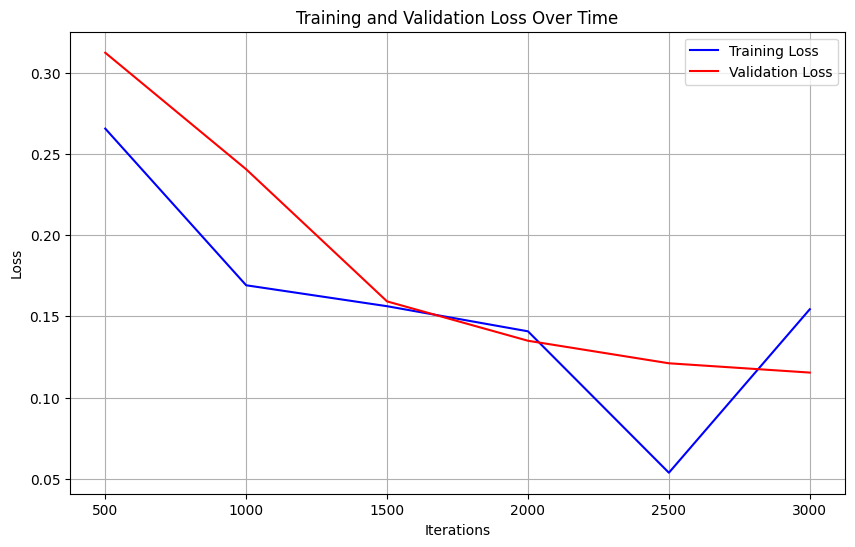

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iterations, train_losses, label='Training Loss', color='blue')
plt.plot(iterations, val_losses, label='Validation Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()


## **How about doing this with GPU?**

This code implements a Feedforward Neural Network (FNN) for MNIST classification using PyTorch, with support for GPU acceleration. It follows these steps:

1. Load the MNIST dataset using torchvision.datasets.MNIST.
2. Make the dataset iterable using DataLoader.
3. Define a neural network model with three hidden layers and ReLU activation.
4. Move the model to GPU if available to accelerate training.
5. Define the loss function (CrossEntropyLoss) for classification.
6. Use the SGD optimizer to update model weights.
7. Train the model using backpropagation, while periodically evaluating its accuracy on the test set.

In [10]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.autograd import Variable

root_folder = '/content/drive/My Drive/IK ML Resources/Computer Vision 1'
'''
STEP 1: LOADING DATASET
'''

# Load MNIST dataset (Training & Test sets)
train_dataset = dsets.MNIST(root=root_folder,
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root=root_folder,
                           train=False,
                           transform=transforms.ToTensor())

'''
STEP 2: MAKING DATASET ITERABLE
'''

# Define batch size
batch_size = 100

# Define number of iterations and epochs
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)  # Convert to integer

# Create DataLoader for training set
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)  # Shuffle for randomness

# Create DataLoader for test set
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)  # No shuffling for test set

'''
STEP 3: CREATE MODEL CLASS
'''

class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedforwardNeuralNetModel, self).__init__()

        # Fully connected layers with ReLU activation
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(hidden_dim, output_dim)  # Output layer

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)

        out = self.fc2(out)
        out = self.relu2(out)

        out = self.fc3(out)
        out = self.relu3(out)

        out = self.fc4(out)  # No activation function at the output layer
        return out

'''
STEP 4: INSTANTIATE MODEL CLASS
'''

# Define input, hidden, and output layer sizes
input_dim = 28 * 28  # 784 input features (flattened MNIST images)
hidden_dim = 100  # Hidden layer neurons
output_dim = 10  # 10 output classes (digits 0-9)

# Instantiate model
model = FeedforwardNeuralNetModel(input_dim, hidden_dim, output_dim)

#######################
#  USE GPU FOR MODEL  #
#######################

# Move model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

'''
STEP 5: INSTANTIATE LOSS CLASS
'''

# Cross-entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()

'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''

# Define learning rate
learning_rate = 0.1

# Use SGD optimizer to update model parameters
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 7: TRAIN THE MODEL
'''

iter = 0  # Track number of iterations

# Lists to store loss values for plotting
train_losses = []
val_losses = []
iterations = []


# Training loop
for epoch in range(num_epochs):

    model.train() # Set model to train mode

    for _, (images, labels) in enumerate(train_loader):

        #######################
        #  USE GPU FOR MODEL  #
        #######################
        images = images.view(-1, 28*28).requires_grad_().to(device)  # Flatten images & move to GPU
        labels = labels.to(device)  # Move labels to GPU

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: Compute predictions
        outputs = model(images)

        # Compute loss: CrossEntropyLoss includes Softmax
        train_loss = criterion(outputs, labels)

        # Backward pass: Compute gradients
        train_loss.backward()

        # Update model parameters
        optimizer.step()

        iter += 1  # Increment iteration counter

        # Evaluate model every 500 iterations
        if iter % 500 == 0:
            model.eval() # Set model to evaluation mode

            # Initialize variables for evaluation
            val_loss_total = 0
            correct = 0
            total = 0

            # Evaluate model on the test dataset
            with torch.no_grad():
              for val_images, val_labels in test_loader:
                  #######################
                  #  USE GPU FOR MODEL  #
                  #######################
                  val_images = images.view(-1, 28*28).requires_grad_().to(device)
                  val_labels = labels.to(device)

                  # Forward pass: Get predictions
                  val_outputs = model(val_images)

                  # Accumulate validation loss
                  val_loss_total += criterion(val_outputs, val_labels).item()

                  # Get class with the highest probability
                  _, predicted = torch.max(val_outputs.data, 1)

                  # Count total labels
                  total += labels.size(0)

                  #######################
                  #  USE GPU FOR MODEL  #
                  #######################
                  # Ensure correct comparison even with GPU tensors
                  correct += (predicted == val_labels).sum().item()

            # Calculate average validation loss
            avg_val_loss = val_loss_total / len(test_loader)

            # Compute accuracy
            accuracy = 100 * correct / total

            # Store loss values for plotting
            train_losses.append(train_loss.item())
            val_losses.append(avg_val_loss)
            iterations.append(iter)

            # Print training progress
            print(f'Iteration: {iter}. Train Loss: {train_loss.item():.4f}. Val Loss: {avg_val_loss:.4f}. Accuracy: {accuracy:.2f}%')

            model.train() # Set model back to train mode


Iteration: 500. Train Loss: 0.2789. Val Loss: 0.1844. Accuracy: 94.00%
Iteration: 1000. Train Loss: 0.1559. Val Loss: 0.1046. Accuracy: 95.00%
Iteration: 1500. Train Loss: 0.1115. Val Loss: 0.0572. Accuracy: 99.00%
Iteration: 2000. Train Loss: 0.0858. Val Loss: 0.0434. Accuracy: 99.00%
Iteration: 2500. Train Loss: 0.1963. Val Loss: 0.0883. Accuracy: 97.00%
Iteration: 3000. Train Loss: 0.1764. Val Loss: 0.0877. Accuracy: 96.00%


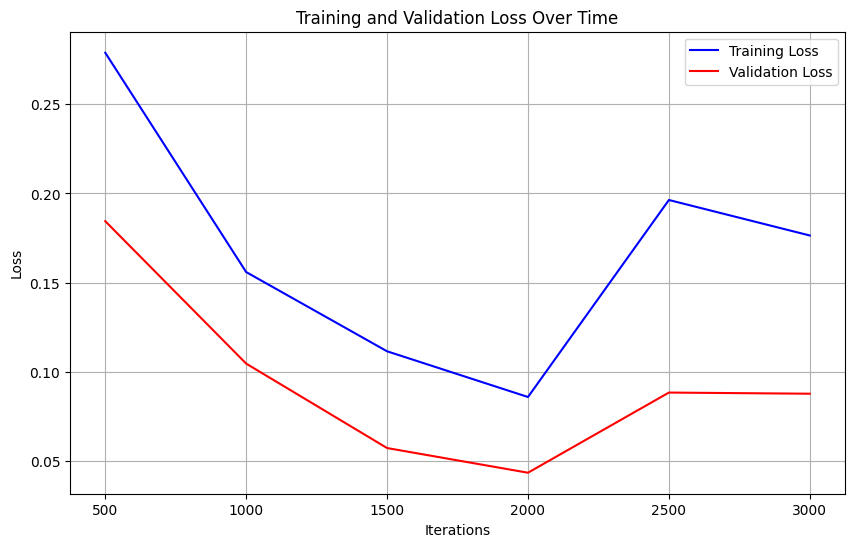

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iterations, train_losses, label='Training Loss', color='blue')
plt.plot(iterations, val_losses, label='Validation Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Interpreting the FFNN Results

##  **Interpreting the FFNN Results**

###  **Model Performance**
- **Final Accuracy:** **96.76%** after **3000 iterations**
- **Loss Trend:** Steady decrease indicating effective learning by the model over time.



###  **Insights**
- **Flattened Input Limitation:**  
  FFNN processes images as flattened vectors (28×28 → 784 pixels), ignoring important spatial relationships (edges, corners, and patterns) present in images.

- **Gradual Accuracy Improvement:**  
  Accuracy steadily improved over time but eventually plateaued. This plateau occurs because FFNNs cannot effectively utilize spatial information for feature extraction.



###  **Why is Accuracy Lower Compared to CNN?**
- **Lack of Spatial Awareness:**  
  FFNN treats each pixel independently without capturing spatial context, leading to less efficient pattern recognition.

- **Limited Feature Extraction:**  
  Spatial structures and local features (edges, textures) critical for image classification are not efficiently learned by FFNNs, unlike CNNs, which are specifically designed to capture these spatial patterns.


###  **Limitations**
- While FFNN provides a solid baseline for basic classification tasks, its inability to leverage spatial relationships significantly limits performance in image-based tasks, making CNN a better choice for such applications.


# **MNIST Classification with a CNN**

## **What is a Convolutional Neural Network (CNN)?**

A **Convolutional Neural Network (CNN)** is specifically designed for image processing:
- Uses **convolutional layers** to extract **spatial features** from images.
- Employs **pooling layers** to reduce dimensionality while preserving key information.
- CNNs outperform FFNNs in **image classification tasks** due to local feature extraction.

### **How CNN Processes MNIST Data**

1. **Convolutional Layers:** Detect patterns like edges and textures.
2. **Pooling Layers:** Reduce spatial dimensions while keeping essential features.
3. **Fully Connected Layer:** Transforms extracted features into digit predictions.

## **STEP 1: LOADING DATASET**  

In this step, we load the MNIST dataset, which consists of grayscale images of handwritten digits (0-9). The dataset is provided by Torchvision's datasets.MNIST module, and we apply transformations to prepare the data for training.

- `train=True`: Loads the training dataset.
- `train=False`: Loads the test dataset for evaluation.
- `transform=transforms.ToTensor()`: Converts images from PIL format to PyTorch tensors, normalizing pixel values to the range [0,1].
- `download=True`: Downloads the dataset if it is not already available in the specified directory (./data).

In [12]:
# Importing the necessary libraries

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.autograd import Variable
from torchsummary import summary

root_folder = '/content/drive/My Drive/IK ML Resources/Computer Vision 1'

In [13]:
'''
STEP 1: LOADING DATASET
'''

# Load MNIST training dataset
train_dataset = dsets.MNIST(root=root_folder,  # Directory where dataset is stored
                            train=True,  # Load training data
                            transform=transforms.ToTensor(),  # Convert images to tensors (normalize to [0,1])
                            download=True)  # Download dataset if not available

# Load MNIST test dataset
test_dataset = dsets.MNIST(root=root_folder,  # Directory where dataset is stored
                           train=False,  # Load test data
                           transform=transforms.ToTensor())  # Convert images to tensors


## **STEP 2: MAKING DATASET ITERABLE**

In this step, we prepare the dataset for **efficient training and evaluation** using **PyTorch's DataLoader**.  

- **Batch Processing:** Instead of loading one image at a time, we group images into batches for efficient computation.  
- **Shuffling:** Randomizes the order of images in each epoch to improve model generalization.  
- **Iterations Calculation:** The total number of iterations (`n_iters`) determines how many times the model processes batches.  
- **Epochs Calculation:** We compute the number of full dataset passes (`num_epochs`) based on the dataset size and batch size.  

This setup ensures that the data is efficiently loaded and fed into the **Convolutional Neural Network (CNN)**.


In [14]:
'''
STEP 2: MAKING DATASET ITERABLE
'''

# Define batch size for training and evaluation
batch_size = 100

# Define total number of iterations
n_iters = 3000

# Compute number of epochs based on dataset size and iterations
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)  # Convert to integer

# Create DataLoader for training set
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)  # Shuffle training data for better generalization

# Create DataLoader for test set
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)  # No need to shuffle test data


## **STEP 3: CREATE MODEL CLASS**


In this step, we define a **Convolutional Neural Network (CNN) model** for MNIST digit classification using PyTorch’s `nn.Module`. The architecture consists of:  

1. **Two Convolutional Layers (`Conv2d`)**  
   - Extracts spatial features from the input image using **5×5 kernels**.  
   - The first layer has **16 filters**, and the second has **32 filters**.  

2. **ReLU Activation (`ReLU()`)**  
   - Applies **non-linearity** after each convolutional layer to introduce complexity.  

3. **Max Pooling Layers (`MaxPool2d`)**  
   - Reduces feature map size using **2×2 pooling**, which helps retain important information while reducing computational cost.  

4. **Fully Connected Layer (`Linear`)**  
   - Flattens the extracted features into a **vector** and passes it to a **fully connected layer** that outputs **10 classes (digits 0-9)**.  

This CNN model is designed to **efficiently learn spatial features** from images and classify handwritten digits accurately.  


In [15]:
'''
STEP 3: CREATE MODEL CLASS
'''

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # First Convolutional Layer: Input (1,28,28) → Output (16,24,24)
        self.cnn1 = nn.Conv2d(in_channels=1,    # Grayscale image (1 channel)
                              out_channels=16,  # 16 feature maps
                              kernel_size=5,    # 5x5 filter size
                              stride=1,         # Move 1 pixel at a time
                              padding=0)        # No padding
        self.relu1 = nn.ReLU()  # Activation function

        # First Max Pooling Layer: Input (16,24,24) → Output (16,12,12)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # 2x2 pooling reduces size by half

        # Second Convolutional Layer: Input (16,12,12) → Output (32,8,8)
        self.cnn2 = nn.Conv2d(in_channels=16,  # Input channels from previous layer
                              out_channels=32,  # 32 feature maps
                              kernel_size=5,    # 5x5 filter size
                              stride=1,         # Move 1 pixel at a time
                              padding=0)        # No padding
        self.relu2 = nn.ReLU()  # Activation function

        # Second Max Pooling Layer: Input (32,8,8) → Output (32,4,4)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)  # 2x2 pooling reduces size by half

        # Fully Connected Layer: Input (32*4*4) → Output (10)
        self.fc1 = nn.Linear(32 * 4 * 4, 10)  # Output 10 classes for digits 0-9

    def forward(self, x):
        # First Convolutional Layer + Activation
        out = self.cnn1(x)
        out = self.relu1(out)

        # First Max Pooling
        out = self.maxpool1(out)

        # Second Convolutional Layer + Activation
        out = self.cnn2(out)
        out = self.relu2(out)

        # Second Max Pooling
        out = self.maxpool2(out)

        # Flatten output tensor for the fully connected layer
        # Input: (batch_size, 32, 4, 4) → Output: (batch_size, 32*4*4)
        out = out.view(out.size(0), -1)

        # Fully Connected Layer (Readout)
        out = self.fc1(out)

        return out


## **STEP 4: INSTANTIATE MODEL CLASS**

In this step, we create an **instance of the CNN model** and move it to the **GPU (if available)** for faster training.  

- **Model Instantiation (`model = CNNModel()`)**  
  - Creates an object of the `CNNModel` class defined earlier.  
  - The model is now ready for training and inference.  

- **GPU Acceleration (`model.to(device)`)**  
  - Uses `torch.device("cuda:0" if torch.cuda.is_available() else "cpu")` to check for GPU availability.  
  - If a **GPU is available**, the model is moved to **CUDA memory** for **faster computation**.  
  - If no GPU is detected, the model runs on **CPU**.  

This setup ensures **efficient training by utilizing GPU acceleration** when available.  


In [16]:
'''
STEP 4: INSTANTIATE MODEL CLASS
'''

# Create an instance of the CNN model
model = CNNModel()

#######################
#  USE GPU FOR MODEL  #
#######################

# Check if GPU is available; otherwise, use CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move model to the selected device (GPU or CPU)
model.to(device)

CNNModel(
  (cnn1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=10, bias=True)
)

**Conv2d-1: 416 parameters**

* Input channels: 1 (grayscale image)
* Output channels: 16
* Filter size: 5×5
* Calculation: (1 × 5 × 5 × 16) + 16 = 400 + 16 = 416
* The "+16" accounts for bias terms (one per output channel)

**ReLU-2 & MaxPool2d-3: 0 parameters**

These are non-parametric operations that don't have learnable weights

**Conv2d-4: 12,832 parameters**

* Input channels: 16 (from previous conv layer)
* Output channels: 32
* Filter size: 5×5
* Calculation: (16 × 5 × 5 × 32) + 32 = 12,800 + 32 = 12,832

**ReLU-5 & MaxPool2d-6: 0 parameters**

Again, no learnable parameters

**Linear-7: 5,130 parameters**

* Input features: 32 × 4 × 4 = 512 (flattened from previous layer)
* Output features: 10 (10-class classification)
* Calculation: (512 × 10) + 10 = 5,120 + 10 = 5,130
* The "+10" is for bias terms

**Summary:**

* Convolutional layers: params = (input_channels × kernel_height × kernel_width × output_channels) + output_channels
* Linear layers: params = (input_features × output_features) + output_features
* The bias terms add one parameter per output channel/neuron
* Activation functions and pooling layers don't contribute to the parameter count

In [17]:
summary(model, input_size=(1, 28, 28)) ##observe the number of params

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 24, 24]             416
              ReLU-2           [-1, 16, 24, 24]               0
         MaxPool2d-3           [-1, 16, 12, 12]               0
            Conv2d-4             [-1, 32, 8, 8]          12,832
              ReLU-5             [-1, 32, 8, 8]               0
         MaxPool2d-6             [-1, 32, 4, 4]               0
            Linear-7                   [-1, 10]           5,130
Total params: 18,378
Trainable params: 18,378
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.07
Estimated Total Size (MB): 0.27
----------------------------------------------------------------


## **STEP 5: INSTANTIATE LOSS CLASS**

In this step, we define the **loss function** that measures how well the model’s predictions match the actual labels.  

- **`nn.CrossEntropyLoss()`**  
  - Commonly used for **multi-class classification tasks**.  
  - Combines **Softmax activation** and **Negative Log Likelihood Loss (NLLLoss)**.  
  - Encourages the model to assign higher probabilities to the correct class.  

This loss function is ideal for training a CNN on **MNIST**, where each image belongs to one of **10 digit classes (0-9)**.


In [18]:
'''
STEP 5: INSTANTIATE LOSS CLASS
'''

# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss applies Softmax + NLLLoss


## **STEP 6: INSTANTIATE OPTIMIZER CLASS**

In this step, we define the **optimizer** responsible for updating the model’s parameters to minimize the loss.  

- **`torch.optim.SGD()` (Stochastic Gradient Descent)**  
  - A widely used optimization algorithm for deep learning.  
  - Updates model parameters using computed gradients from backpropagation.  
  - Works well for simpler architectures like CNNs on MNIST.  

- **Learning Rate (`lr=0.01`)**  
  - Controls how much the model updates its parameters in each step.  
  - A **higher learning rate** speeds up training but may lead to instability.  
  - A **lower learning rate** ensures stable learning but may slow down convergence.  

This setup ensures the model **efficiently updates weights** to improve accuracy during training.

In [19]:
'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''

# Define the learning rate (step size for parameter updates)
learning_rate = 0.01  # A moderate learning rate for stable training

# Initialize the optimizer (SGD - Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(),  # Update model weights
                            lr=learning_rate)  # Learning rate controls update size

## **STEP 7: TRAIN THE MODEL**

In this step, we **train the Convolutional Neural Network (CNN)** using **forward and backward propagation**. The training loop follows these steps:

### **Training Process**  
1. **Iterate through multiple epochs (`num_epochs`)**  
   - Each epoch is a full pass through the dataset.  

2. **For each batch of images (`train_loader`):**  
   - Move images and labels to **GPU (if available)**.  
   - **Forward pass:** Compute predictions using the CNN model.  
   - **Compute Loss:** Compare predictions with actual labels using **CrossEntropyLoss**.  
   - **Backward pass:** Compute gradients using **backpropagation**.  
   - **Optimizer Step:** Update the model’s parameters using **Stochastic Gradient Descent (SGD)**.  

3. **Every 500 iterations:**  
   - Evaluate the model on the **test dataset**.  
   - Compute **accuracy** by comparing predictions with ground truth labels.  
   - Print **training progress**, including **loss and accuracy**.  

This setup ensures the **CNN model continuously improves its performance** with each epoch.


In [20]:
'''
STEP 7: TRAIN THE MODEL
'''

# Initialize iteration counter
iter = 0
train_losses = []
val_losses = []
iterations = []

# Loop through multiple epochs (full passes over the dataset)
for epoch in range(num_epochs):

    model.train()

    for _, (images, labels) in enumerate(train_loader):

        #######################
        #  USE GPU FOR MODEL  #
        #######################
        images = images.requires_grad_().to(device)  # Move images to GPU and enable gradient tracking
        labels = labels.to(device)  # Move labels to GPU

        # Reset gradients to prevent accumulation from previous steps
        optimizer.zero_grad()

        # Forward pass: Get model predictions (logits)
        outputs = model(images)

        # Compute loss: Cross-Entropy Loss (includes Softmax)
        train_loss = criterion(outputs, labels)

        # Backward pass: Compute gradients
        train_loss.backward()

        # Update model parameters using optimizer
        optimizer.step()

        iter += 1  # Increment iteration counter

        # Evaluate model every 500 iterations
        if iter % 500 == 0:
            model.eval()

            val_loss_total = 0
            correct = 0
            total = 0

            # Evaluate model on the test dataset
            with torch.no_grad():
              for val_images, val_labels in test_loader:
                  #######################
                  #  USE GPU FOR MODEL  #
                  #######################
                  val_images = val_images.requires_grad_().to(device)  # Move test images to GPU
                  val_labels = val_labels.to(device)  # Move test labels to GPU

                  # Forward pass: Get predictions
                  val_outputs = model(val_images)

                  # Accumulate validation loss
                  val_loss_total += criterion(val_outputs, val_labels).item()

                  # Get class with the highest probability
                  _, predicted = torch.max(outputs.data, 1)

                  # Update total count
                  total += labels.size(0)

                  #######################
                  #  USE GPU FOR MODEL  #
                  #######################
                  # Ensure correct comparison even with GPU tensors
                  if torch.cuda.is_available():
                      correct += (predicted.cpu() == labels.cpu()).sum()
                  else:
                      correct += (predicted == labels).sum()

            # Compute average validation loss
            avg_val_loss = val_loss_total / len(test_loader)

            # Compute accuracy
            accuracy = 100 * correct / total

            # Store loss values for plotting
            train_losses.append(train_loss.item())
            val_losses.append(avg_val_loss)
            iterations.append(iter)

            # Print training progress
            print(f'Iteration: {iter}. Train Loss: {train_loss.item():.4f}. Val Loss: {avg_val_loss:.4f}. Accuracy: {accuracy:.2f}%')


Iteration: 500. Train Loss: 0.4089. Val Loss: 0.3978. Accuracy: 88.00%
Iteration: 1000. Train Loss: 0.2122. Val Loss: 0.2331. Accuracy: 95.00%
Iteration: 1500. Train Loss: 0.1684. Val Loss: 0.1813. Accuracy: 94.00%
Iteration: 2000. Train Loss: 0.1180. Val Loss: 0.1472. Accuracy: 96.00%
Iteration: 2500. Train Loss: 0.0852. Val Loss: 0.1307. Accuracy: 98.00%
Iteration: 3000. Train Loss: 0.1169. Val Loss: 0.1119. Accuracy: 96.00%


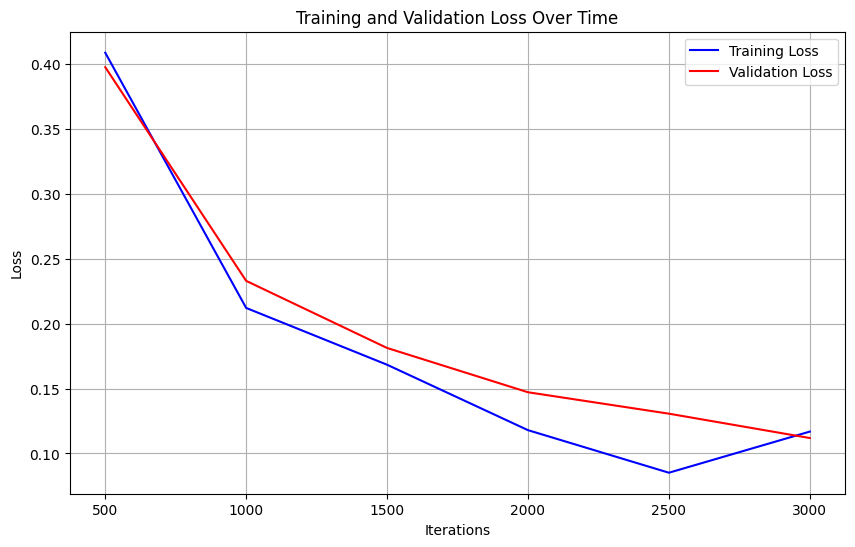

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iterations, train_losses, label='Training Loss', color='blue')
plt.plot(iterations, val_losses, label='Validation Loss', color='red')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Interpreting the CNN Results

## **Model Performance:**

- Achieved a final accuracy of 96.21% after 3000 iterations.
- Loss values dropped quickly at the start, stabilizing toward the end, highlighting efficient feature extraction.

## Insights:

  - CNNs effectively utilize spatial information through convolutional and pooling layers.
  - Hierarchical learning of spatial features (edges, textures, patterns) significantly boosts performance in image recognition tasks.
  -Demonstrated faster convergence and better robustness compared to FFNN.

## Advantages:
  - Automatic feature extraction enables CNNs to generalize better to variations within the dataset, making them ideal for image classification.
  ---

## **Why CNN is Preferred for Image Data?**
1. **Loss Value:**
   - Similar to FFNN, **CrossEntropyLoss** decreases over epochs.
   - Since CNN captures spatial patterns, it typically converges faster than FFNN.

2. **Accuracy Improvement:**
   - Accuracy improves consistently as CNN extracts better features using convolution layers.
   - Since CNN captures **edges, corners, and textures**, it classifies images better than FFNN.

3. **Why CNN Performs Better?**
   - CNN extracts spatial features, improving classification for structured data like images.
   - Pooling layers reduce overfitting by making feature extraction invariant to small shifts.
   - The hierarchical feature extraction process makes CNN more robust.

## Comparison: FFNN vs. CNN for MNIST Classification

| Feature                | Feedforward Neural Network (FFNN) | Convolutional Neural Network (CNN) |
|------------------------|----------------------------------|-----------------------------------|
| **Architecture**       | Fully Connected Layers (Dense)  | Convolutional + Pooling Layers |
| **Feature Extraction** | Manual (Flattened Input)        | Automatic (Spatial Features)   |
| **Input Handling**     | 1D Flattened Vector (784 inputs) | 2D Image with Preserved Structure |
| **Training Speed**     | Slower Convergence              | Takes longer per epoch due to convolution operations, but need fewer epochs to achieve good performance |
| **Performance on Images** | Moderate                     | Excellent |
| **Scalability**        | Struggles with larger images   | Handles larger images efficiently |
| **Computational Cost** | Higher (More parameters)       | Lower (Fewer parameters) |
| **Memory Usage**       | Less                            | More (Stores feature maps) |
| **Best Use Case**      | Basic Classification Tasks      | Image Processing, Complex Patterns |


**Training w CNN Plot:**

* Shows very smooth, consistent convergence for both training and validation loss
* Both curves decrease steadily and remain close together throughout training
* No signs of overfitting - validation loss tracks training loss well
* Final losses converge to around 0.11-0.12





**Training w FFNN Plot:**

* Shows more erratic training behavior
* Training loss decreases initially but then spikes dramatically around iteration 2000-2500
* Validation loss appears more stable but still shows some instability
* Clear signs of training instability or possible overfitting

**Observations:**

* The CNN shows better stability - This aligns with expectations since CNNs are generally more robust for image tasks

* The FFNN shows training instability - The dramatic spike in training loss around iteration 2000 suggests possible issues with learning rate, gradient explosions, or severe overfitting

* Convergence speed - Contrary to FFNN, the CNN appears to have smoother convergence, while the FFNN shows erratic behavior

## Key Takeaways

1. FFNN is simple but lacks spatial feature learning.
  - Works for basic classification but struggles with image-based tasks.

2. CNN is superior for image classification.
  - Learns hierarchical spatial features automatically.
  - More robust to shifts, rotations, and variations in handwritten digits.

3. Training efficiency:

  - CNN converges faster due to its hierarchical feature extraction.
  - FFNN requires more epochs to achieve comparable results.

4. Computational requirements:

- CNN requires fewer parameters and generalizes better for images.
- FFNN needs more parameters but underperforms for structured visual data.
